In [40]:
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.metrics import r2_score, accuracy_score,f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression

In [41]:
data_path = "fifa_world_cup_2026_player_performance.csv"

df = pd.read_csv(data_path)

df.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


In [42]:
# Checking missing values or null data

print(f"Missing Values : {df.isnull().sum().max()}")

Missing Values : 0


In [43]:
# Reading information about data

print("Reading the data types : \n", df.info())


<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    
 14  stadium          

In [44]:
# Checking unique feature type object

cols = df.select_dtypes(include=['str', 'object'])

for i, col_name in enumerate(cols):
    unique_count = df[col_name].unique().sum()
    
    print(f"Index {i}: '{col_name}' has {unique_count} unique values")

Index 0: 'player_id' has P00055P00070P00066P00073P00059P00072P00058P00078P00056P00074P00069P00071P00076P00067P00057P00062P00077P00064P00061P00068P00060P00075P00063P00065P00053P00054P01225P01241P01243P01240P01228P01239P01247P01229P01244P01233P01238P01246P01226P01227P01237P01234P01235P01236P01245P01232P01248P01231P01230P01242P01224P01223P00626P00635P00650P00629P00638P00633P00636P00632P00639P00630P00642P00648P00646P00647P00634P00637P00628P00641P00631P00640P00644P00649P00643P00645P00625P00627P00133P00141P00147P00145P00140P00136P00153P00135P00154P00144P00156P00138P00137P00146P00142P00149P00134P00155P00152P00150P00148P00139P00151P00143P00131P00132P01041P01054P01059P01048P01063P01045P01062P01058P01050P01065P01066P01064P01047P01057P01056P01060P01049P01055P01061P01053P01044P01046P01051P01052P01042P01043P01017P01031P01036P01030P01023P01037P01019P01034P01038P01039P01033P01026P01020P01022P01029P01025P01021P01024P01040P01035P01032P01028P01027P01018P01016P01015P01172P01196P01193P01178P01186P01183P01

In [45]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

In [46]:
dfe = df.copy()

drop_cols = ['player_id', 'player_name', 'match_id', 'club_name']
dfe = dfe.drop(columns=drop_cols, errors='ignore')

dfe['tournament_stage'] = dfe['tournament_stage'].map({    
    'Group Stage': 0, 'Round of 32': 1, 'Round of 16': 2,
    'Quarter Finals': 3, 'Semi Finals': 4, 'Third Place Match': 5, 'Final': 6
})

dfe['match_result'] = dfe['match_result'].map({'W': 2, 'D': 1, 'L': 0})
dfe['preferred_foot'] = dfe['preferred_foot'].map({'Left': 0, 'Right': 1})

ohe_cols = dfe.select_dtypes(include=['object', 'str']).columns.tolist()
print("OHE cols:", ohe_cols)

dfe = pd.get_dummies(dfe, columns=ohe_cols, dtype=int)

# Verify
print(dfe.select_dtypes(include=['object', 'str']).columns.tolist())  # should be []
print(dfe.shape)

# Now split for both tasks
# Regression
X_reg = dfe.drop(['player_rating', 'performance_score'], axis=1)
y_reg = dfe['player_rating']

# Classification  
X_clf = dfe.drop(['match_result'], axis=1)
y_clf = dfe['match_result']


OHE cols: ['nationality', 'team', 'position', 'match_date', 'stadium', 'city', 'opponent_team']
[]
(54600, 295)


C:\Users\62877\AppData\Local\Temp\ipykernel_24160\1539823980.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position', y='player_rating',
C:\Users\62877\AppData\Local\Temp\ipykernel_24160\1539823980.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='position', y='age',


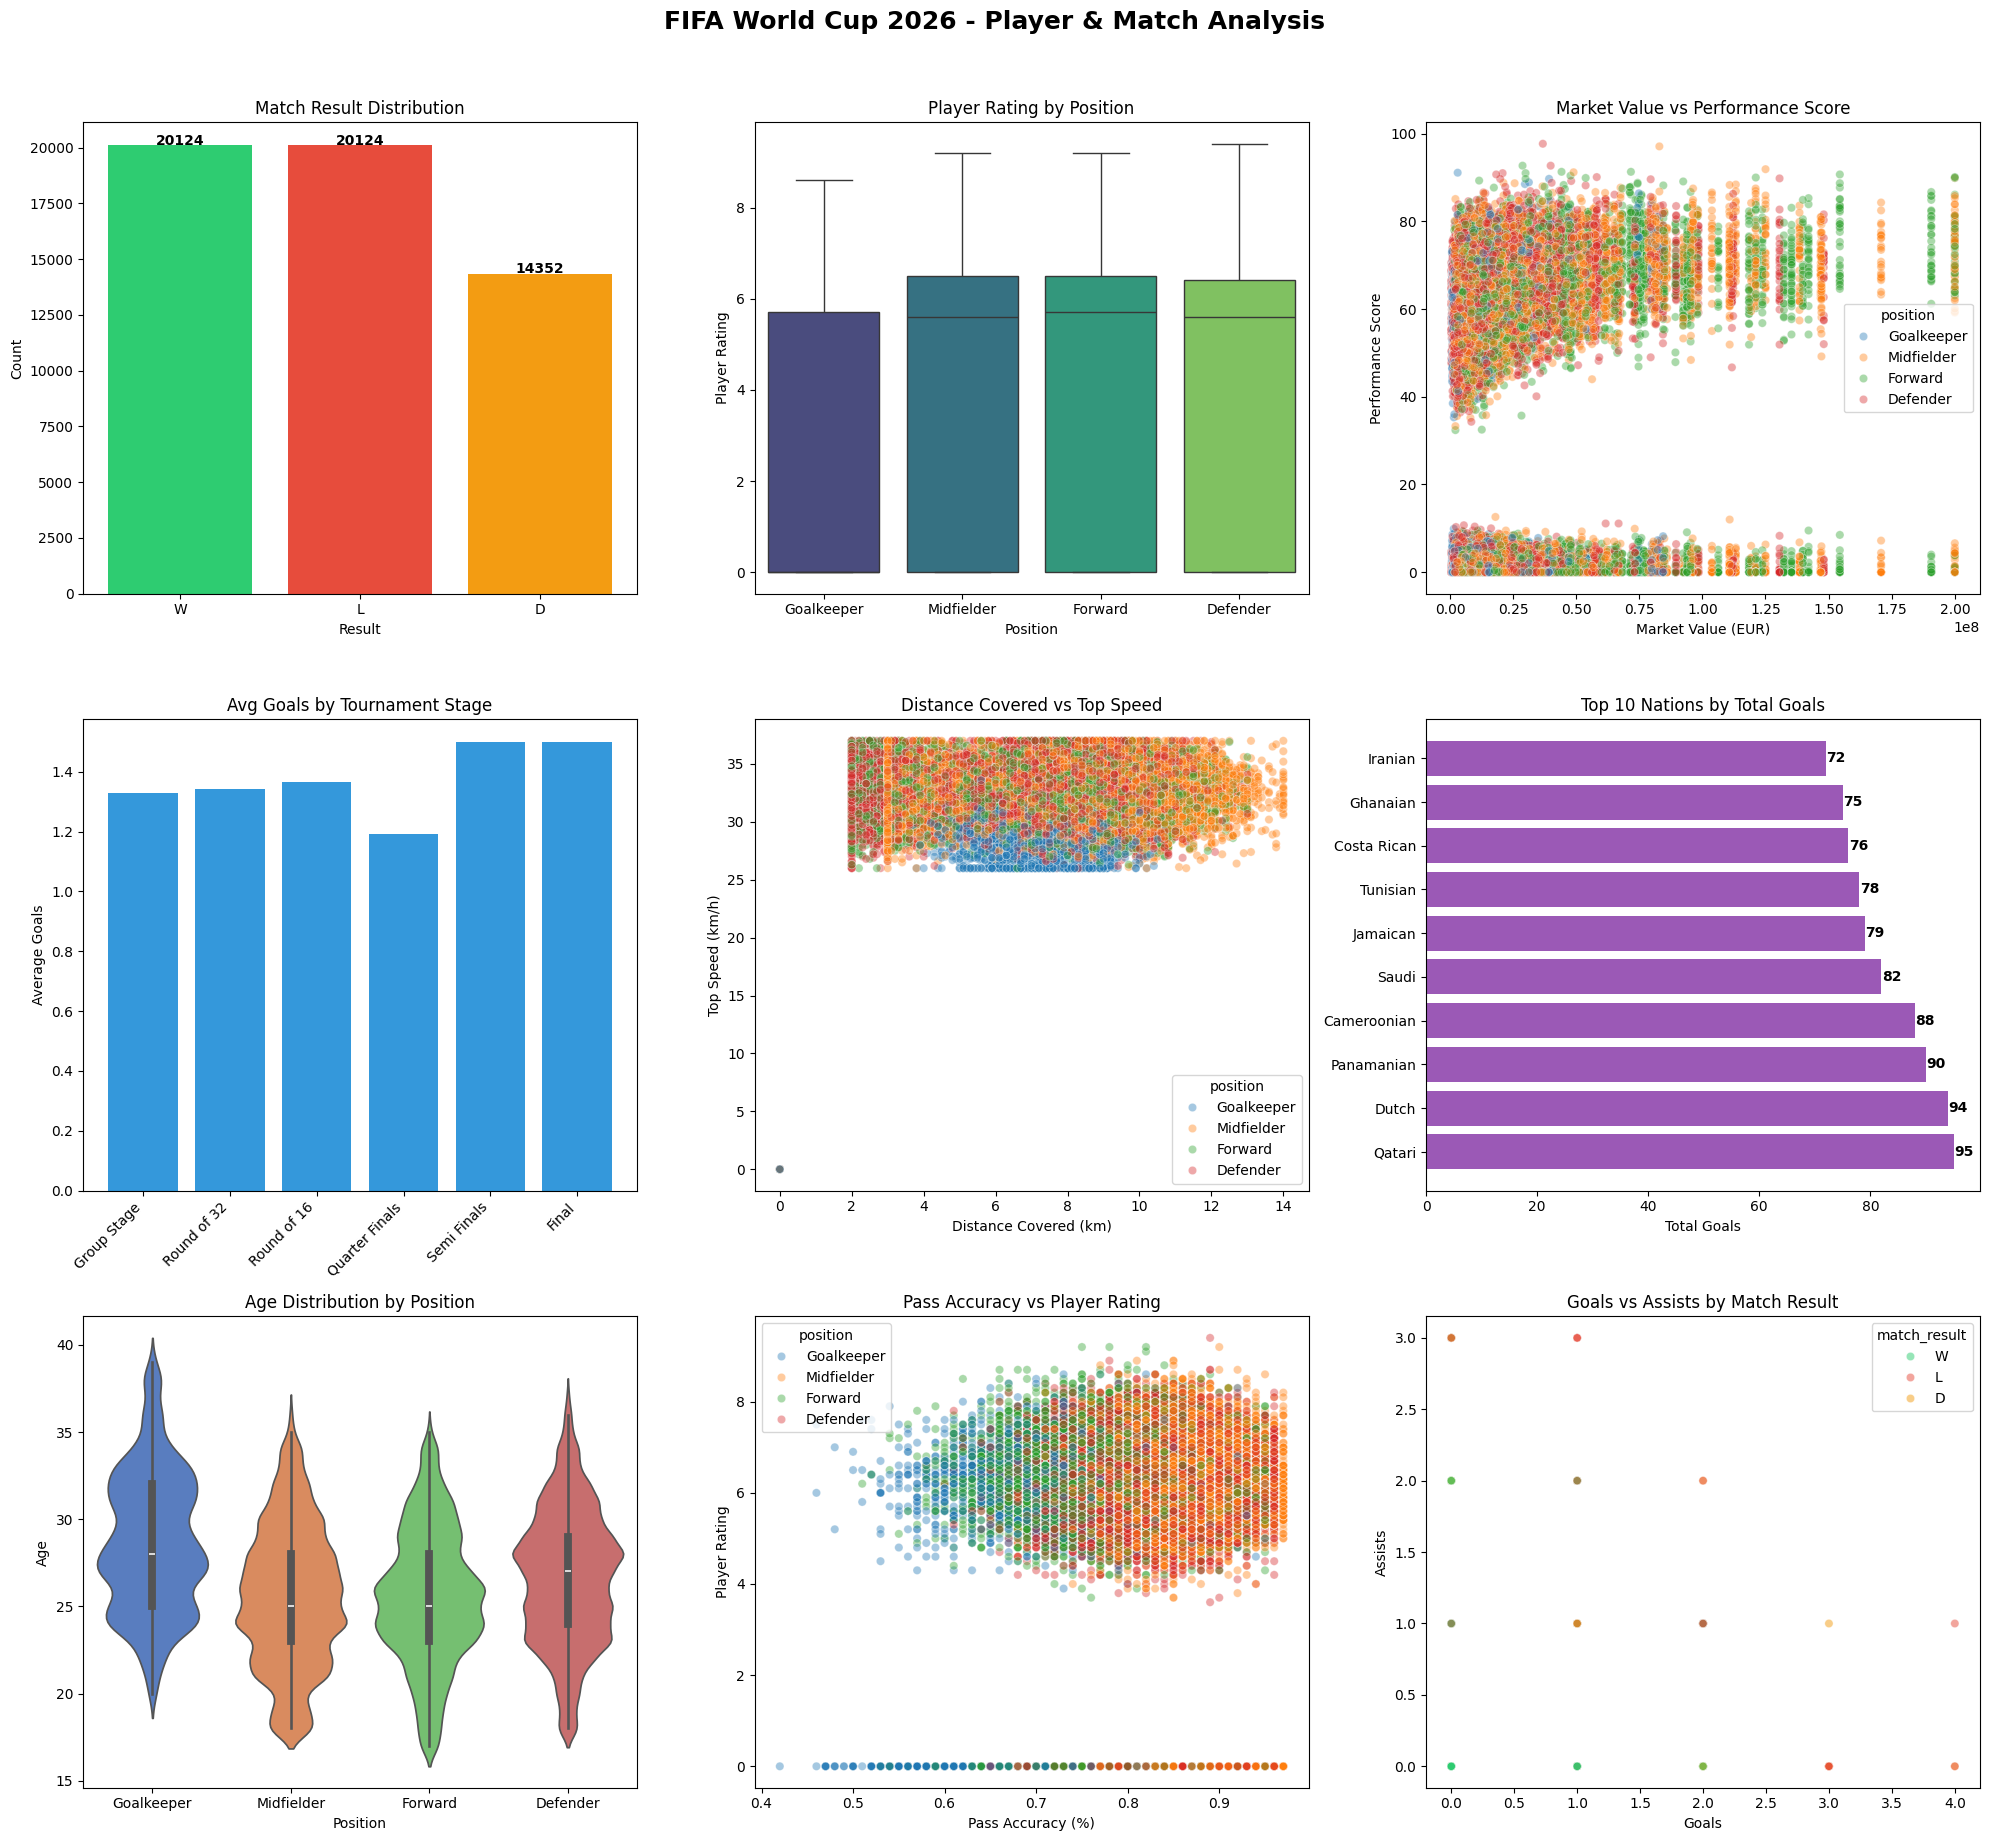

In [47]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle('FIFA World Cup 2026 - Player & Match Analysis', 
             fontsize=18, fontweight='bold', y=1.02)

# 1. Match Result Distribution
match_colors = {'W': '#2ecc71', 'D': '#f39c12', 'L': '#e74c3c'}
match_counts = df['match_result'].value_counts()
axes[0, 0].bar(match_counts.index, match_counts.values, 
               color=[match_colors[x] for x in match_counts.index])
axes[0, 0].set_title('Match Result Distribution')
axes[0, 0].set_xlabel('Result')
axes[0, 0].set_ylabel('Count')
for i, (idx, val) in enumerate(match_counts.items()):
    axes[0, 0].text(i, val + 10, str(val), ha='center', fontweight='bold')

# 2. Player Rating by Position
sns.boxplot(data=df, x='position', y='player_rating',
            palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Player Rating by Position')
axes[0, 1].set_xlabel('Position')
axes[0, 1].set_ylabel('Player Rating')

# 3. Market Value vs Performance Score
sns.scatterplot(data=df, x='market_value_eur', y='performance_score',
                hue='position', alpha=0.4, ax=axes[0, 2])
axes[0, 2].set_title('Market Value vs Performance Score')
axes[0, 2].set_xlabel('Market Value (EUR)')
axes[0, 2].set_ylabel('Performance Score')

# 4. Goals by Tournament Stage
stage_order = ['Group Stage', 'Round of 32', 'Round of 16', 
               'Quarter Finals', 'Semi Finals', 'Final']
stage_goals = df.groupby('tournament_stage')['goals_team'].mean().reindex(stage_order)
axes[1, 0].bar(range(len(stage_goals)), stage_goals.values, color='#3498db')
axes[1, 0].set_xticks(range(len(stage_goals)))
axes[1, 0].set_xticklabels(stage_order, rotation=45, ha='right')
axes[1, 0].set_title('Avg Goals by Tournament Stage')
axes[1, 0].set_ylabel('Average Goals')

# 5. Top Speed vs Distance Covered
sns.scatterplot(data=df, x='distance_covered_km', y='top_speed_kmh',
                hue='position', alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_title('Distance Covered vs Top Speed')
axes[1, 1].set_xlabel('Distance Covered (km)')
axes[1, 1].set_ylabel('Top Speed (km/h)')

# 6. Top 10 Nations by Goals
top_nations = df.groupby('nationality')['goals'].sum().nlargest(10)
axes[1, 2].barh(top_nations.index, top_nations.values, color='#9b59b6')
axes[1, 2].set_title('Top 10 Nations by Total Goals')
axes[1, 2].set_xlabel('Total Goals')
for i, val in enumerate(top_nations.values):
    axes[1, 2].text(val + 0.1, i, str(val), va='center', fontweight='bold')

# 7. Age Distribution by Position
sns.violinplot(data=df, x='position', y='age',
               palette='muted', ax=axes[2, 0])
axes[2, 0].set_title('Age Distribution by Position')
axes[2, 0].set_xlabel('Position')
axes[2, 0].set_ylabel('Age')

# 8. Pass Accuracy vs Player Rating
sns.scatterplot(data=df, x='pass_accuracy', y='player_rating',
                hue='position', alpha=0.4, ax=axes[2, 1])
axes[2, 1].set_title('Pass Accuracy vs Player Rating')
axes[2, 1].set_xlabel('Pass Accuracy (%)')
axes[2, 1].set_ylabel('Player Rating')

# 9. Goals vs Assists (Top Performers)
sns.scatterplot(data=df, x='goals', y='assists',
                hue='match_result', alpha=0.5,
                palette={'W': '#2ecc71', 'D': '#f39c12', 'L': '#e74c3c'},
                ax=axes[2, 2])
axes[2, 2].set_title('Goals vs Assists by Match Result')
axes[2, 2].set_xlabel('Goals')
axes[2, 2].set_ylabel('Assists')

plt.tight_layout()
plt.show()

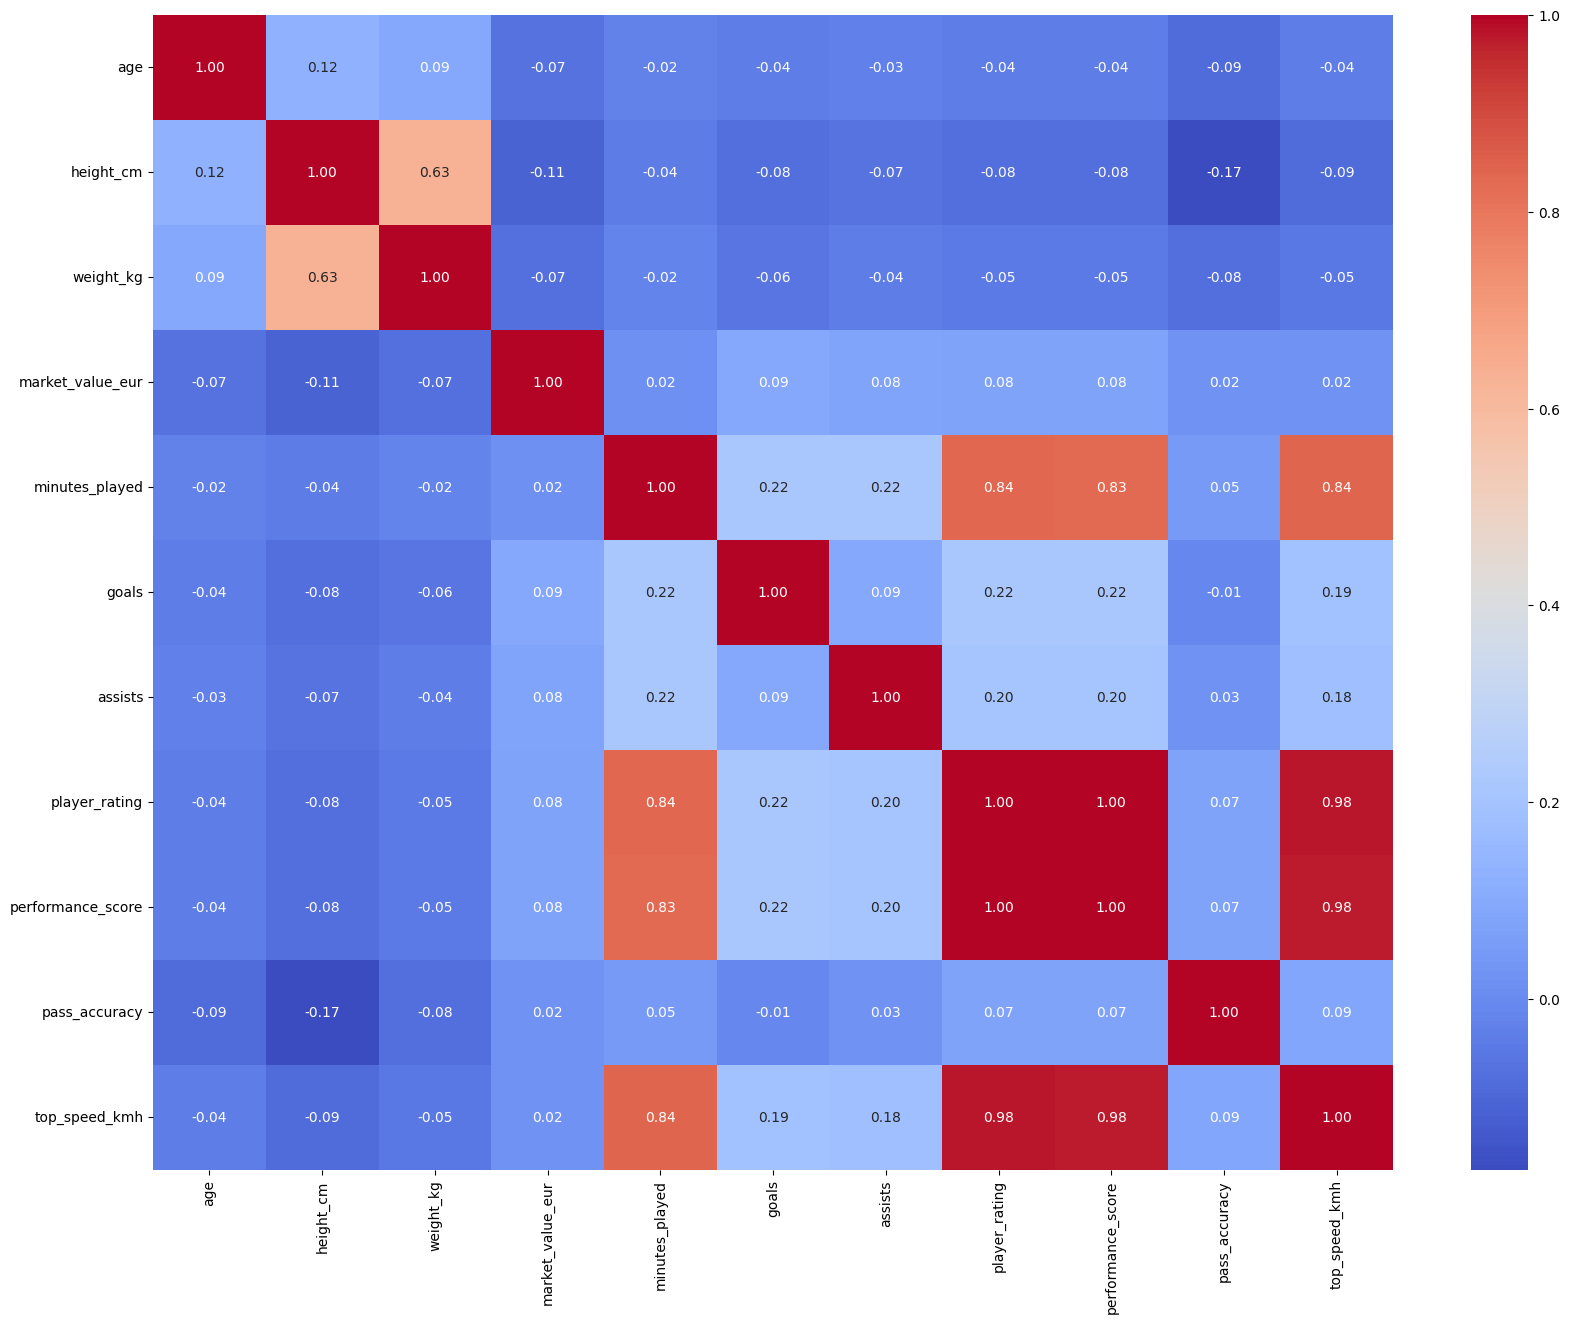

In [48]:
# EDA heatmap to get best feature

plt.figure(figsize=(20,15))

num_cols = ['age', 'height_cm', 'weight_kg', 'market_value_eur',
            'minutes_played', 'goals', 'assists', 'player_rating',
            'performance_score', 'pass_accuracy', 'top_speed_kmh']

sns.heatmap(dfe[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.show()

In [49]:
reg_drop = [
    'player_rating',        # target
    'performance_score',    # correlated to target
    'match_result',         # classification target
    'tournament_rating',    # might be derived
]

y_reg = dfe['player_rating']
X_reg = dfe.drop(columns=reg_drop, errors='ignore')

clf_drop = [
    'match_result',         # target
    'player_rating',        # might leak
    'performance_score',    # might leak
    'goals_team',           # directly determines W/L/D → leakage!
    'goals_opponent',       # directly determines W/L/D → leakage!
]

y_clf = dfe['match_result']
X_clf = dfe.drop(columns=clf_drop, errors='ignore')

# Train test split For Regression 

X_train_reg, X_valid_reg, y_train_reg, y_valid_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Train test for Classification 

X_train_clf, X_valid_clf, y_train_clf, y_valid_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42 )


print("Label test count data")
print("Train shape : ", X_train_reg.shape)
print("Length of data : ",len(y_train_reg))

print(X_train_reg)

Label test count data
Train shape :  (43680, 291)
Length of data :  43680
       age  jersey_number  height_cm  weight_kg  preferred_foot  \
47727   26             22        184         74               1   
43570   22             16        177         72               1   
34407   22              5        187         76               1   
43135   18             16        186         81               1   
34694   25             16        186         76               1   
...    ...            ...        ...        ...             ...   
44732   22             17        174         71               1   
54343   27             11        185         73               1   
38158   32              8        185         77               1   
860     27             10        181         80               1   
15795   31              9        179         66               1   

       market_value_eur  tournament_stage  goals_team  goals_opponent  \
47727           8032380                 3       

In [50]:
# Scalling data x train 

scaler = StandardScaler()

# Scalling for regression X and y
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_valid_reg_scaled = scaler.fit_transform(X_valid_reg)

# Scalling for classification X and y

X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_valid_clf_scaled = scaler.fit_transform(X_valid_clf)



Rebalancing Data using SMOTETOMEK

In [51]:
smote = SMOTETomek(random_state=42)

X_train_clf_scaled_balanced, y_train_clf_scaled_balanced = smote.fit_resample(
    X_train_clf_scaled, 
    y_train_clf
)
print("Label test count data")
print("Train Regession Shape  : ", X_train_reg_scaled.shape)
print("Train Classification (Setelah SMOTE) Shape : ", X_train_clf_scaled_balanced.shape)

Label test count data
Train Regession Shape  :  (43680, 291)
Train Classification (Setelah SMOTE) Shape :  (48112, 290)


Time predict : 1.4258202000000892 seconds


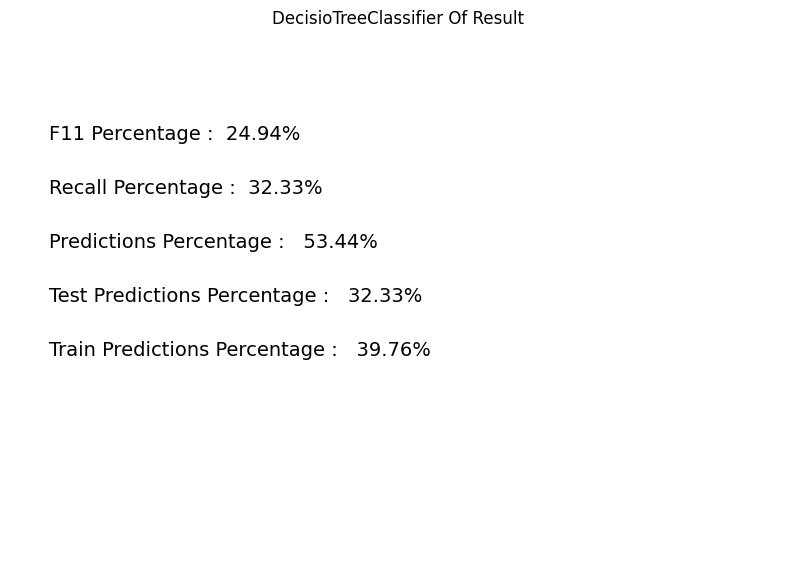

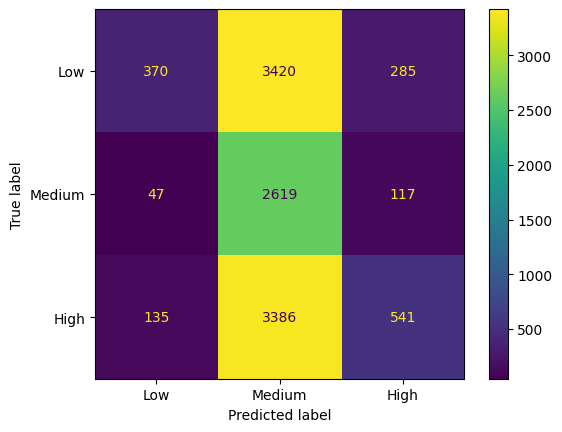


Calculating Learning Curve...


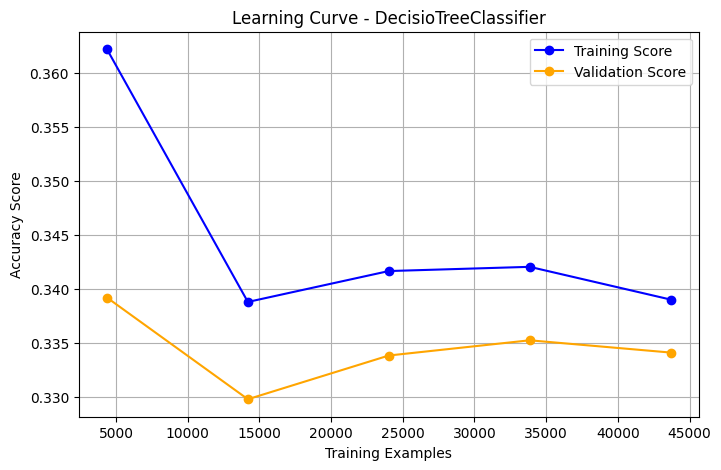

In [52]:
# Classification step using logisticregression 

time_start = time.perf_counter()

model_dtc = DecisionTreeClassifier(          
    max_depth=8,           # increase from 4
    min_samples_split=5,   # decrease from 20
    min_samples_leaf=2,    # decrease from 10
    random_state=42,
    class_weight='balanced'  
)


model_dtc.fit(X_train_clf_scaled_balanced, y_train_clf_scaled_balanced)

train_predictions = model_dtc.predict(X_train_clf_scaled_balanced)
test_predictions = model_dtc.predict(X_valid_clf_scaled)

# Evaluating
train_accuracy = accuracy_score(y_train_clf_scaled_balanced, train_predictions)
test_accuracy = accuracy_score(y_valid_clf, test_predictions)

Recall = recall_score(y_valid_clf, test_predictions, average='weighted')
Precision = precision_score(y_valid_clf, test_predictions, average='weighted')
F11 = f1_score(y_valid_clf, test_predictions, average='weighted')
cm = confusion_matrix(y_valid_clf, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("DecisioTreeClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Precision * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"]).plot()

plt.show()

# Learning Curve
print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5) # Menguji dari 10% hingga 100% ukuran data

X_full = np.concatenate((X_train_clf_scaled, X_valid_clf_scaled))
y_full = np.concatenate((y_train_clf.values, y_valid_clf.values))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_dtc,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - DecisioTreeClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()
